In [2]:
import numpy as np
import pandas as pd
import plotly
import plotly.figure_factory as ff
import plotly.graph_objs as go
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)

In [3]:
data = pd.read_csv('task_b.csv')
data=data.iloc[:,1:]

In [4]:
data.head()

,f1,f2,f3,y
0,-195.871045,-14843.084171,5.532140,1.0
1,-1217.183964,-4068.124621,4.416082,1.0
2,9.138451,4413.412028,0.425317,0.0
3,363.824242,15474.760647,1.094119,0.0
4,-768.812047,-7963.932192,1.870536,0.0


In [5]:
data.corr()['y']

f1    0.067172
f2   -0.017944
f3    0.839060
y     1.000000
Name: y, dtype: float64

In [6]:
data.std()

f1      488.195035
f2    10403.417325
f3        2.926662
y         0.501255
dtype: float64

In [7]:
X=data[['f1','f2','f3']].values
Y=data['y'].values
print(X.shape)
print(Y.shape)

(200, 3)
(200,)


# What if our features are with different variance 

<pre>
* <b>As part of this task you will observe how linear models work in case of data having feautres with different variance</b>
* <b>from the output of the above cells you can observe that var(F2)>>var(F1)>>Var(F3)</b>

> <b>Task1</b>:
    1. Apply Logistic regression(SGDClassifier with logloss) on 'data' and check the feature importance
    2. Apply SVM(SGDClassifier with hinge) on 'data' and check the feature importance

> <b>Task2</b>:
    1. Apply Logistic regression(SGDClassifier with logloss) on 'data' after standardization 
       i.e standardization(data, column wise): (column-mean(column))/std(column) and check the feature importance
    2. Apply SVM(SGDClassifier with hinge) on 'data' after standardization 
       i.e standardization(data, column wise): (column-mean(column))/std(column) and check the feature importance

</pre>

<h3><font color='blue'> Make sure you write the observations for each task, why a particular feautre got more importance than others</font></h3>

## Task 1.1: Apply Logistic regression(SGDClassifier with logloss) on 'data' and check the                                    feature importance

In [25]:
from sklearn import linear_model
Lr_model = linear_model.SGDClassifier(eta0=0.0001, alpha=0.0001, loss='log', random_state=15, penalty='l2', tol=1e-3, verbose=2, learning_rate='constant')
Lr_model

SGDClassifier(alpha=0.0001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.0001,
              fit_intercept=True, l1_ratio=0.15, learning_rate='constant',
              loss='log', max_iter=1000, n_iter_no_change=5, n_jobs=None,
              penalty='l2', power_t=0.5, random_state=15, shuffle=True,
              tol=0.001, validation_fraction=0.1, verbose=2, warm_start=False)

In [26]:
Lr_model.fit(X=X, y=Y)

-- Epoch 1
Norm: 1.08, NNZs: 3, Bias: -0.001751, T: 200, Avg. loss: 2516.147588
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 0.61, NNZs: 3, Bias: -0.001551, T: 400, Avg. loss: 2621.694380
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 0.35, NNZs: 3, Bias: -0.001850, T: 600, Avg. loss: 3285.222158
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 0.64, NNZs: 3, Bias: -0.003527, T: 800, Avg. loss: 3142.216822
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 0.48, NNZs: 3, Bias: -0.004027, T: 1000, Avg. loss: 3009.886714
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 1.40, NNZs: 3, Bias: -0.003523, T: 1200, Avg. loss: 3032.001946
Total training time: 0.00 seconds.
Convergence after 6 epochs took 0.00 seconds


SGDClassifier(alpha=0.0001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.0001,
              fit_intercept=True, l1_ratio=0.15, learning_rate='constant',
              loss='log', max_iter=1000, n_iter_no_change=5, n_jobs=None,
              penalty='l2', power_t=0.5, random_state=15, shuffle=True,
              tol=0.001, validation_fraction=0.1, verbose=2, warm_start=False)

Feature: 0, Score: 0.37170
Feature: 1, Score: -1.34464
Feature: 2, Score: 0.12669


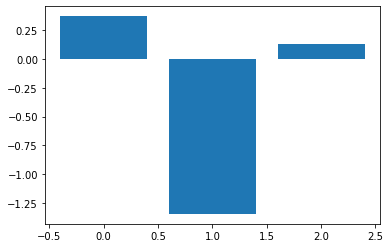

In [27]:
# https://machinelearningmastery.com/calculate-feature-importance-with-python/

from matplotlib import pyplot
%matplotlib inline

# get importance
importance = Lr_model.coef_[0]
# summarize feature importance
for i,v in enumerate(importance):
    print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()

## Task 1.2: Apply SVM(SGDClassifier with hinge) on 'data' and check the feature importance


In [31]:
svm_model = linear_model.SGDClassifier(eta0=0.0001, alpha=0.0001, loss='hinge', random_state=15, penalty='l2', tol=1e-3, verbose=2, learning_rate='constant')
svm_model

SGDClassifier(alpha=0.0001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.0001,
              fit_intercept=True, l1_ratio=0.15, learning_rate='constant',
              loss='hinge', max_iter=1000, n_iter_no_change=5, n_jobs=None,
              penalty='l2', power_t=0.5, random_state=15, shuffle=True,
              tol=0.001, validation_fraction=0.1, verbose=2, warm_start=False)

In [32]:
svm_model.fit(X=X, y=Y)

-- Epoch 1
Norm: 0.61, NNZs: 3, Bias: -0.001600, T: 200, Avg. loss: 2634.084615
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 0.68, NNZs: 3, Bias: -0.001100, T: 400, Avg. loss: 2593.136418
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 0.76, NNZs: 3, Bias: -0.000900, T: 600, Avg. loss: 3308.216351
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 0.77, NNZs: 3, Bias: -0.002700, T: 800, Avg. loss: 3155.085896
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 0.93, NNZs: 3, Bias: -0.002800, T: 1000, Avg. loss: 3080.501847
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 0.43, NNZs: 3, Bias: -0.002700, T: 1200, Avg. loss: 3011.887174
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 0.69, NNZs: 3, Bias: -0.002200, T: 1400, Avg. loss: 3002.132514
Total training time: 0.00 seconds.
Convergence after 7 epochs took 0.00 seconds


SGDClassifier(alpha=0.0001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.0001,
              fit_intercept=True, l1_ratio=0.15, learning_rate='constant',
              loss='hinge', max_iter=1000, n_iter_no_change=5, n_jobs=None,
              penalty='l2', power_t=0.5, random_state=15, shuffle=True,
              tol=0.001, validation_fraction=0.1, verbose=2, warm_start=False)

Feature: 0, Score: 0.04249
Feature: 1, Score: 0.02585
Feature: 2, Score: 1.07273


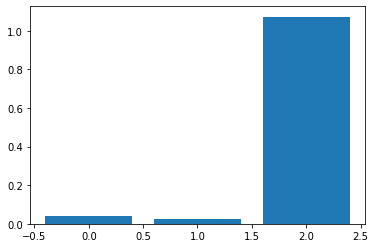

In [41]:
# get importance
importance = svm_model.coef_[0]
# summarize feature importance
for i,v in enumerate(importance):
    print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()

## Observation

1. SVM is based on geometrical properties of the data while logistic regression is based on statistical approaches.That's why svm dosen't affect by high variance features

## Task 2.1: Apply Logistic regression(SGDClassifier with logloss) on 'data' after standardization and check the feature importance

In [34]:
# Standardizing the data.
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [35]:
ss_Lr_model = linear_model.SGDClassifier(eta0=0.0001, alpha=0.0001, loss='log', random_state=15, penalty='l2', tol=1e-3, verbose=2, learning_rate='constant')
ss_Lr_model

SGDClassifier(alpha=0.0001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.0001,
              fit_intercept=True, l1_ratio=0.15, learning_rate='constant',
              loss='log', max_iter=1000, n_iter_no_change=5, n_jobs=None,
              penalty='l2', power_t=0.5, random_state=15, shuffle=True,
              tol=0.001, validation_fraction=0.1, verbose=2, warm_start=False)

In [36]:
ss_Lr_model.fit(X=X, y=Y)

-- Epoch 1
Norm: 0.01, NNZs: 3, Bias: 0.000001, T: 200, Avg. loss: 0.691431
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 0.02, NNZs: 3, Bias: 0.000002, T: 400, Avg. loss: 0.687922
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 0.03, NNZs: 3, Bias: 0.000002, T: 600, Avg. loss: 0.684449
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 0.03, NNZs: 3, Bias: 0.000003, T: 800, Avg. loss: 0.681011
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 0.04, NNZs: 3, Bias: 0.000003, T: 1000, Avg. loss: 0.677608
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 0.05, NNZs: 3, Bias: 0.000003, T: 1200, Avg. loss: 0.674240
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 0.06, NNZs: 3, Bias: 0.000003, T: 1400, Avg. loss: 0.670905
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 0.07, NNZs: 3, Bias: 0.000003, T: 1600, Avg. loss: 0.667605
Total training time: 0.00 seconds.
-- Epoch 9
Norm: 0.07, NNZs: 3, Bias: 0.000002, T: 1800, Avg. loss: 0.664338
Total training time: 0.00 secon

SGDClassifier(alpha=0.0001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.0001,
              fit_intercept=True, l1_ratio=0.15, learning_rate='constant',
              loss='log', max_iter=1000, n_iter_no_change=5, n_jobs=None,
              penalty='l2', power_t=0.5, random_state=15, shuffle=True,
              tol=0.001, validation_fraction=0.1, verbose=2, warm_start=False)

Feature: 0, Score: 0.03851
Feature: 1, Score: -0.00553
Feature: 2, Score: 0.88963


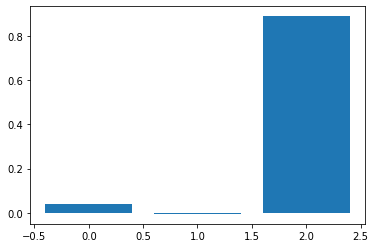

In [37]:
# get importance
importance = ss_Lr_model.coef_[0]
# summarize feature importance
for i,v in enumerate(importance):
    print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()

In [38]:
ss_svm_model = linear_model.SGDClassifier(eta0=0.0001, alpha=0.0001, loss='hinge', random_state=15, penalty='l2', tol=1e-3, verbose=2, learning_rate='constant')
ss_svm_model

SGDClassifier(alpha=0.0001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.0001,
              fit_intercept=True, l1_ratio=0.15, learning_rate='constant',
              loss='hinge', max_iter=1000, n_iter_no_change=5, n_jobs=None,
              penalty='l2', power_t=0.5, random_state=15, shuffle=True,
              tol=0.001, validation_fraction=0.1, verbose=2, warm_start=False)

In [43]:
ss_svm_model.fit(X=X, y=Y)

-- Epoch 1
Norm: 0.02, NNZs: 3, Bias: 0.000000, T: 200, Avg. loss: 0.993111
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 0.03, NNZs: 3, Bias: -0.000000, T: 400, Avg. loss: 0.978934
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 0.05, NNZs: 3, Bias: 0.000000, T: 600, Avg. loss: 0.964757
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 0.07, NNZs: 3, Bias: 0.000000, T: 800, Avg. loss: 0.950580
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 0.08, NNZs: 3, Bias: -0.000000, T: 1000, Avg. loss: 0.936403
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 0.10, NNZs: 3, Bias: 0.000000, T: 1200, Avg. loss: 0.922226
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 0.12, NNZs: 3, Bias: 0.000000, T: 1400, Avg. loss: 0.908049
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 0.13, NNZs: 3, Bias: 0.000000, T: 1600, Avg. loss: 0.893873
Total training time: 0.00 seconds.
-- Epoch 9
Norm: 0.15, NNZs: 3, Bias: 0.000000, T: 1800, Avg. loss: 0.879696
Total training time: 0.00 sec

SGDClassifier(alpha=0.0001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.0001,
              fit_intercept=True, l1_ratio=0.15, learning_rate='constant',
              loss='hinge', max_iter=1000, n_iter_no_change=5, n_jobs=None,
              penalty='l2', power_t=0.5, random_state=15, shuffle=True,
              tol=0.001, validation_fraction=0.1, verbose=2, warm_start=False)

Feature: 0, Score: 0.04249
Feature: 1, Score: 0.02585
Feature: 2, Score: 1.07273


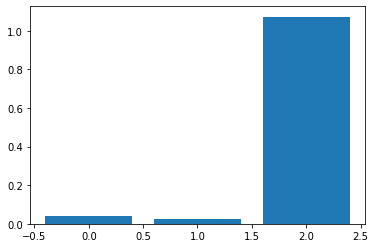

In [44]:
# get importance
importance = ss_svm_model.coef_[0]
# summarize feature importance
for i,v in enumerate(importance):
    print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()

## Observation

After applying standardization the model shows not much difference in the features